In [4]:
from chemplot import Plotter

# read your .smi file manually
smiles = []
ids = []

with open("drug_Standardized.smi", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            smiles.append(parts[0])
            ids.append(parts[1])

print("Loaded molecules:", len(smiles))

# create ChemPlot object
cp = Plotter.from_smiles(smiles, sim_type="structural")

# PCA
cp.pca()
cp.interactive_plot(
    size=700,
    show_plot=True,
    filename="interactive_pca_plot.html",
    title="Interactive PCA chemical space map"
)

Loaded molecules: 7730


figure(id='p1149', ...)

In [2]:
from chemplot import Plotter

# read your .smi file manually
smiles = []
ids = []

with open("drug_Standardized.smi", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            smiles.append(parts[0])
            ids.append(parts[1])

print("Loaded molecules:", len(smiles))

# create ChemPlot object
cp = Plotter.from_smiles(smiles, sim_type="structural")

# UMAP
cp.umap()
cp.interactive_plot(
    size=700,
    show_plot=True,
    filename="interactive_umap_plot.html",
    title="Interactive UMAP chemical space map"
)

Loaded molecules: 7730


figure(id='p1053', ...)

In [3]:
from chemplot import Plotter

# read your .smi file manually
smiles = []
ids = []

with open("drug_Standardized.smi", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            smiles.append(parts[0])
            ids.append(parts[1])

print("Loaded molecules:", len(smiles))

# create ChemPlot object
cp = Plotter.from_smiles(smiles, sim_type="structural")

# t-SNE
cp.tsne()
cp.interactive_plot(
    size=700,
    show_plot=True,
    filename="interactive_tsne_plot.html",
    title="Interactive t-SNE chemical space map"
)

Loaded molecules: 7730


figure(id='p1101', ...)

Data shape for SOM: (7730, 50)
 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.25198593353042936


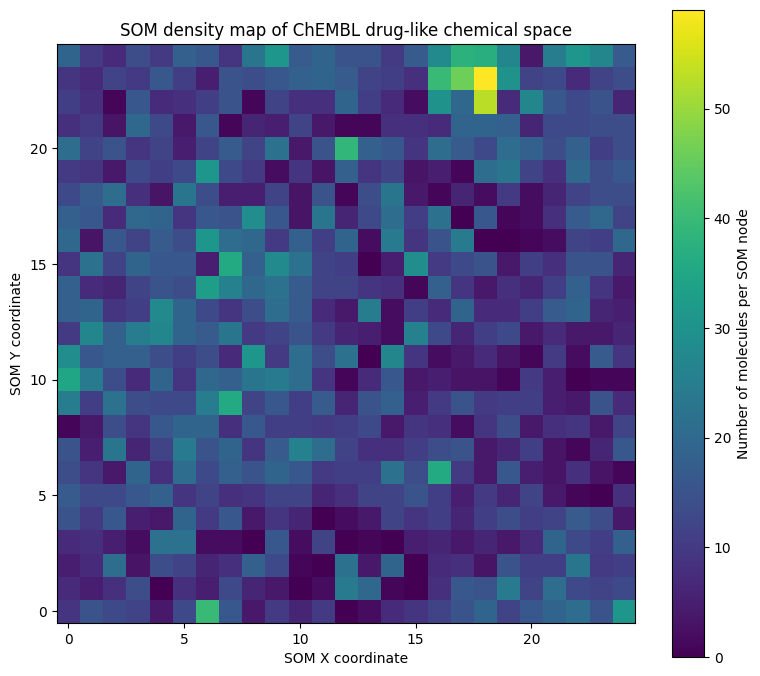

Maximum molecules in one SOM node: 59.0
Number of occupied SOM nodes: 608
Total SOM nodes: 625
Quantization error: 0.25198593353042936


In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_svmlight_file
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD
from minisom import MiniSom


input_file = Path("t3l2u3--DoAllWays.svm")  # or your drug .svm file

X, y = load_svmlight_file(str(input_file))
X = normalize(X)

# Reduce dimensionality first, because SOM on sparse/high-dimensional data can be slow
svd = TruncatedSVD(n_components=50, random_state=42)
X_red = svd.fit_transform(X)

print("Data shape for SOM:", X_red.shape)

# SOM grid size
som_x, som_y = 25, 25

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=X_red.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    random_seed=42
)

som.random_weights_init(X_red)
som.train_random(X_red, num_iteration=5000, verbose=True)

# Count molecules per SOM node
counts = np.zeros((som_x, som_y))

for x in X_red:
    w = som.winner(x)
    counts[w] += 1

plt.figure(figsize=(8, 7))
plt.imshow(counts.T, origin="lower", interpolation="nearest")
plt.colorbar(label="Number of molecules per SOM node")
plt.xlabel("SOM X coordinate")
plt.ylabel("SOM Y coordinate")
plt.title("SOM density map of ChEMBL drug-like chemical space")
plt.tight_layout()
plt.savefig("SOM_density_map.png", dpi=300, bbox_inches="tight")
plt.show()

print("Maximum molecules in one SOM node:", counts.max())
print("Number of occupied SOM nodes:", (counts > 0).sum())
print("Total SOM nodes:", counts.size)
print("Quantization error:", som.quantization_error(X_red))